# Data Profiling, Cleaning & EDA - Operational Analyst
Notebook ini merupakan gabungan dari proses data profiling menyeluruh dan pembersihan data operasional logistik, dilengkapi dengan visualisasi.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_theme(style='whitegrid')

## Fungsi Profiling
Fungsi bantuan untuk memeriksa shape, missing values, dan duplikat pada setiap dataset.

In [13]:
def profile_dataset(df, dataset_name):
    print('\n' + '=' * 80)
    print(f'PROFILING DATASET: {dataset_name.upper()}')
    print('=' * 80)

    # Tampilkan 5 baris pertama
    print('\n5 Baris Pertama Data (df.head()):')
    display(df.head())

    # Shape
    print(f'\nSHAPE DATA: {df.shape[0]:,} baris x {df.shape[1]} kolom')

    # Info tipe data
    print('\nTipe Data (df.dtypes):')
    display(df.dtypes.to_frame('dtype'))

    # Missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Missing_Count': missing,
        'Missing_Percentage': missing_pct.round(2)
    })
    missing_df = missing_df[missing_df['Missing_Count'] > 0]

    print('\nMISSING VALUES:')
    if len(missing_df) > 0:
        display(missing_df)
    else:
        print('   Tidak ada missing values!')

    # Duplicates
    duplicates = df.duplicated().sum()
    dup_pct = (duplicates / len(df)) * 100
    print(f'\nDUPLICATE ROWS: {duplicates:,} ({dup_pct:.2f}%)')

    # Describe numerik
    print('\nStatistik Deskriptif (df.describe()):')
    display(df.describe())

    return df

## 1. Load Data & Basic Profiling
Memuat ketujuh dataset utama dan menjalankan `df.head()`, `df.dtypes`, `df.describe()`, pengecekan duplikat, serta jumlah missing values.

In [14]:
datasets = {
    'orders.csv': 'Orders',
    'order_items.csv': 'Order Items',
    'sellers.csv': 'Sellers',
    'customers.csv': 'Customers',
    'geolocation.csv': 'Geolocation',
    'products.csv': 'Products',
    'order_reviews.csv': 'Order Reviews'
}

all_dfs = {}

for file_path, dataset_name in datasets.items():
    try:
        df = pd.read_csv(file_path)
        profile_dataset(df, dataset_name)
        all_dfs[dataset_name] = df
    except Exception as e:
        print(f'ERROR load {file_path}: {e}')

orders = all_dfs.get('Orders')
items = all_dfs.get('Order Items')
sellers = all_dfs.get('Sellers')
customers = all_dfs.get('Customers')
geolocation = all_dfs.get('Geolocation')
products = all_dfs.get('Products')
order_reviews = all_dfs.get('Order Reviews')


PROFILING DATASET: ORDERS

5 Baris Pertama Data (df.head()):


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



SHAPE DATA: 99,441 baris x 8 kolom

Tipe Data (df.dtypes):


,dtype
order_id,str
customer_id,str
order_status,str
order_purchase_timestamp,str
order_approved_at,str
order_delivered_carrier_date,str
order_delivered_customer_date,str
order_estimated_delivery_date,str



MISSING VALUES:


...

,dtype
review_id,str
order_id,str
review_score,int64
review_comment_title,str
review_comment_message,str
review_creation_date,str
review_answer_timestamp,str



MISSING VALUES:


,Missing_Count,Missing_Percentage
review_comment_title,87656,88.34
review_comment_message,58247,58.70



DUPLICATE ROWS: 0 (0.00%)

Statistik Deskriptif (df.describe()):


,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


## 2. EDA per Tabel
Tinjauan eksplorasi data terpisah untuk setiap dataset agar insight dari masing-masing tabel lebih jelas.


### 2.1 Orders


Shape orders: 99,441 baris x 8 kolom


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



Order status counts:


,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


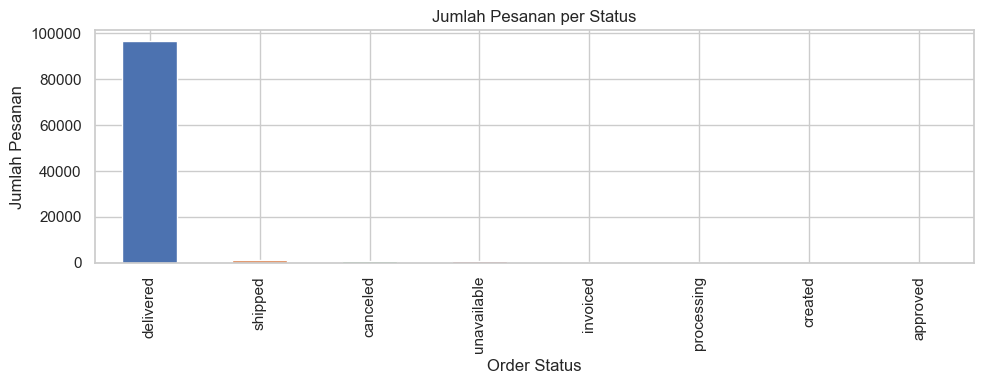

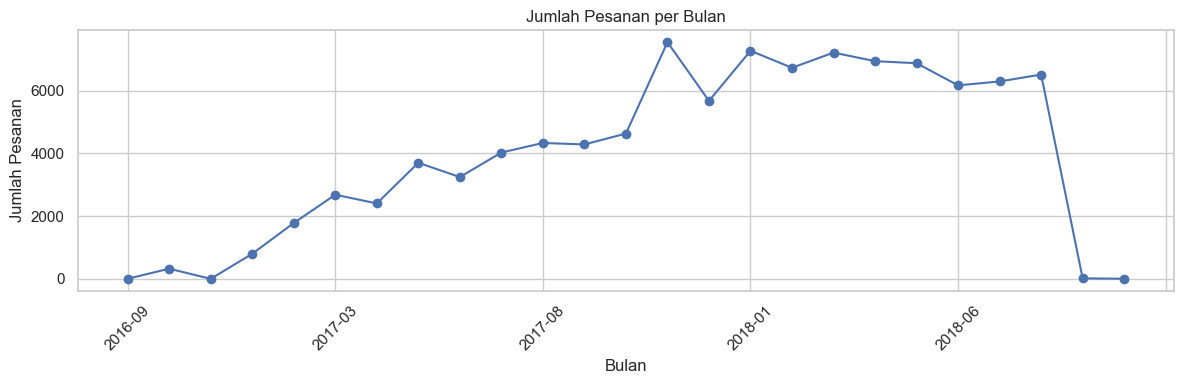

In [15]:
orders_eda = orders.copy()
print(f'Shape orders: {orders_eda.shape[0]:,} baris x {orders_eda.shape[1]} kolom')
display(orders_eda.head())

print('\nOrder status counts:')
display(orders_eda['order_status'].value_counts().to_frame('count'))

orders_eda['order_purchase_timestamp'] = pd.to_datetime(orders_eda['order_purchase_timestamp'], errors='coerce')
orders_eda['purchase_month'] = orders_eda['order_purchase_timestamp'].dt.to_period('M').astype(str)

plt.figure(figsize=(10, 4))
orders_eda['order_status'].value_counts().plot(kind='bar', color=['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b2'])
plt.title('Jumlah Pesanan per Status')
plt.xlabel('Order Status')
plt.ylabel('Jumlah Pesanan')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
monthly_counts = orders_eda['purchase_month'].value_counts().sort_index()
monthly_counts.plot(kind='line', marker='o', color='#4c72b0')
plt.title('Jumlah Pesanan per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Pesanan')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight Orders
- `orders` memiliki beberapa status dengan sebagian besar pesanan berstatus `delivered`.
- Tren pesanan per bulan membantu melihat volume dan potensi seasonality.

### 2.2 Order Items


Shape order_items: 112,650 baris x 7 kolom


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


,product_category_name,product_category_name_english
0,cool_stuff,cool_stuff
1,pet_shop,pet_shop
2,moveis_decoracao,furniture_decor
3,perfumaria,perfumery
4,ferramentas_jardim,garden_tools
5,utilidades_domesticas,housewares
6,telefonia,telephony
8,beleza_saude,health_beauty
9,livros_tecnicos,books_technical
11,fashion_bolsas_e_acessorios,fashion_bags_accessories


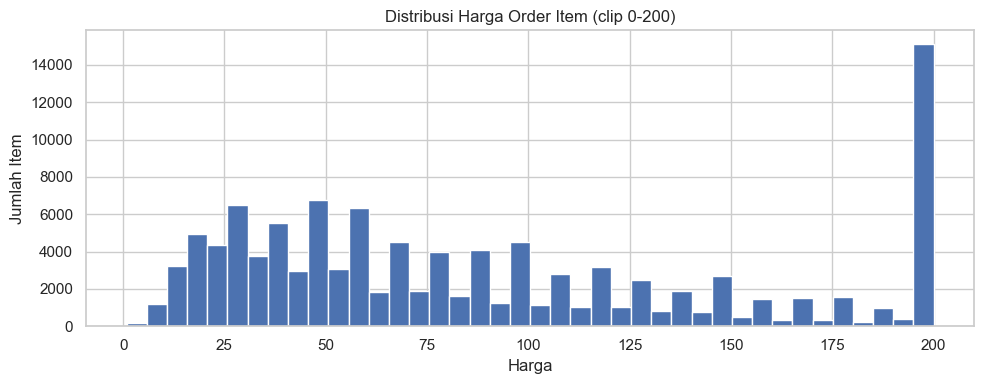

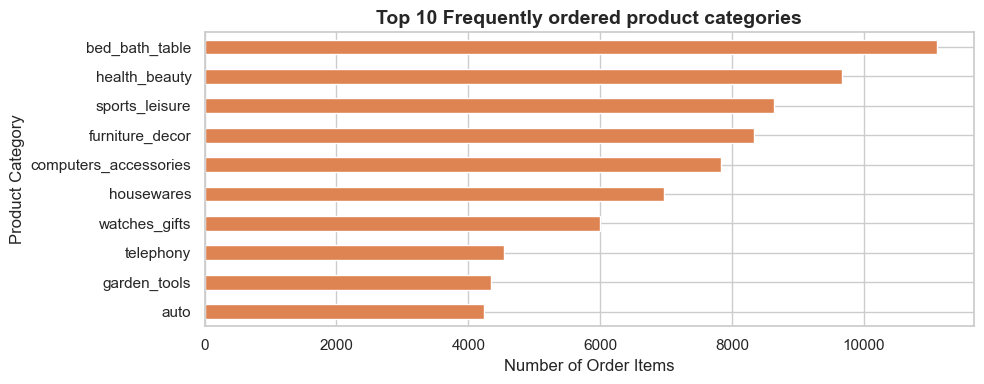

In [27]:
items_eda = items.copy()
print(f'Shape order_items: {items_eda.shape[0]:,} baris x {items_eda.shape[1]} kolom')
display(items_eda.head())

items_eda['price'] = pd.to_numeric(items_eda['price'], errors='coerce')
items_eda = pd.merge(
    items_eda,
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)
items_eda['product_category_name'] = items_eda['product_category_name'].fillna('unknown')
category_translation = pd.read_csv('category_translation.csv')
items_eda = pd.merge(
    items_eda,
    category_translation,
    on='product_category_name',
    how='left'
)

# 3. Handle missing values (jika ada kategori 'unknown' yang tidak ada di tabel translation)
items_eda['product_category_name_english'] = items_eda['product_category_name_english'].fillna('Unknown')

# Cek sekilas hasilnya
display(items_eda[['product_category_name', 'product_category_name_english']].drop_duplicates().head(10))

plt.figure(figsize=(10, 4))
items_eda['price'].dropna().clip(upper=200).hist(bins=40, color='#4c72b0')
plt.title('Distribusi Harga Order Item (clip 0-200)')
plt.xlabel('Harga')
plt.ylabel('Jumlah Item')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))

# Gunakan kolom product_category_name_english
top_categories = items_eda['product_category_name_english'].value_counts().head(10)
top_categories.sort_values().plot(kind='barh', color='#dd8452')
plt.title('Top 10 Frequently ordered product categories', fontsize=14, fontweight='bold')
plt.xlabel('Number of Order Items', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.tight_layout()
plt.show()


### Insight Order Items
- Harga item sebagian besar berada di bawah 200.
- Top 10 produk menunjukkan produk yang paling sering muncul dalam pesanan, berguna untuk inventaris dan promosi.

### 2.3 Sellers


Shape sellers: 3,095 baris x 4 kolom


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


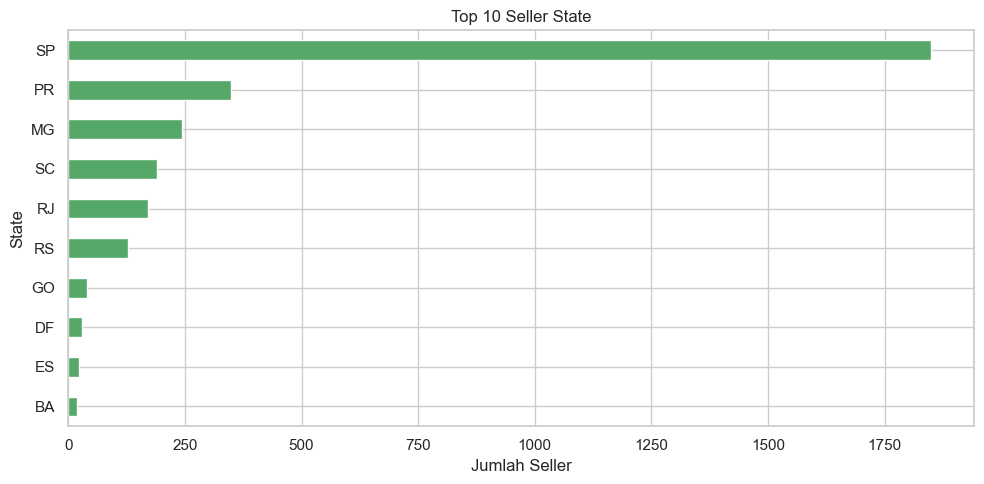

In [17]:
sellers_eda = sellers.copy()
print(f'Shape sellers: {sellers_eda.shape[0]:,} baris x {sellers_eda.shape[1]} kolom')
display(sellers_eda.head())

plt.figure(figsize=(10, 5))
sellers_eda['seller_state'].value_counts().head(10).sort_values().plot(kind='barh', color='#55a868')
plt.title('Top 10 Seller State')
plt.xlabel('Jumlah Seller')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Insight Sellers
- Sebagian besar seller terkonsentrasi di beberapa state utama.
- Informasi ini bisa digunakan untuk fokus pada dukungan dan peningkatan kapabilitas regional.

### 2.4 Customers


Shape customers: 99,441 baris x 5 kolom


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


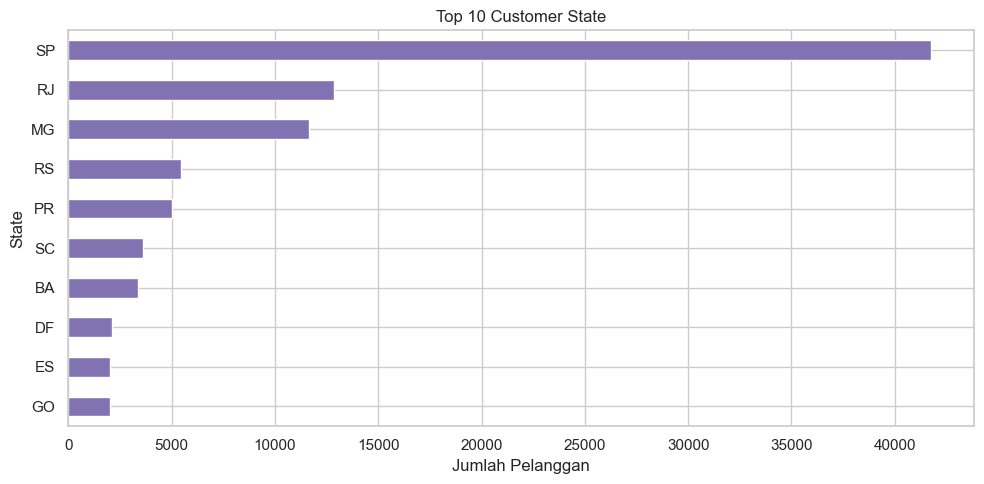

In [18]:
customers_eda = customers.copy()
print(f'Shape customers: {customers_eda.shape[0]:,} baris x {customers_eda.shape[1]} kolom')
display(customers_eda.head())

plt.figure(figsize=(10, 5))
customers_eda['customer_state'].value_counts().head(10).sort_values().plot(kind='barh', color='#8172b2')
plt.title('Top 10 Customer State')
plt.xlabel('Jumlah Pelanggan')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Insight Customers
- Pelanggan tersebar di beberapa state, dengan beberapa wilayah menonjol.
- Ini membantu melihat area permintaan tertinggi dan potensi pengiriman.

### 2.5 Geolocation


Geolocation setelah agregasi: 19,015 baris
Reduksi dari 1,000,163 baris (98.1% duplikat dihapus)


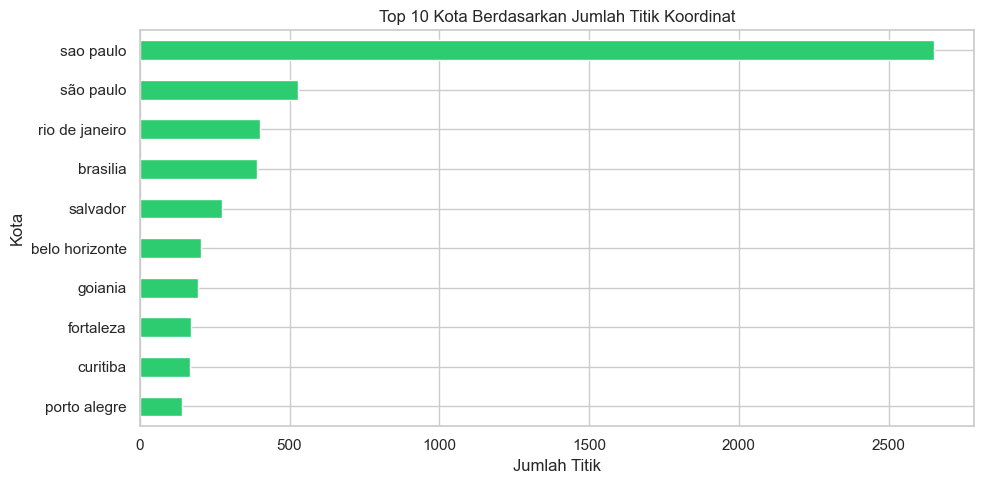

In [37]:
geo_clean = geolocation.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean',
    'geolocation_city': 'first',
    'geolocation_state': 'first'
}).reset_index()

print(f"Geolocation setelah agregasi: {len(geo_clean):,} baris")
print(f"Reduksi dari {len(geolocation):,} baris ({100 - (len(geo_clean)/len(geolocation))*100:.1f}% duplikat dihapus)")

top_cities = geo_clean['geolocation_city'].value_counts().head(10)
plt.figure(figsize=(10, 5))
top_cities.sort_values().plot(kind='barh', color='#2ecc71')
plt.title('Top 10 Kota Berdasarkan Jumlah Titik Koordinat')
plt.xlabel('Jumlah Titik')
plt.ylabel('Kota')
plt.tight_layout()
plt.show()

### Insight Geolocation
- Ada banyak lokasi duplikat, sehingga deduplikasi penting untuk analisis rute yang benar.
- Kota-kota teratas menunjukkan area operasional utama dan potensi bottleneck lokasi.

### 2.6 Products


Translasi kategori berhasil.


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,category_display
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares,housewares


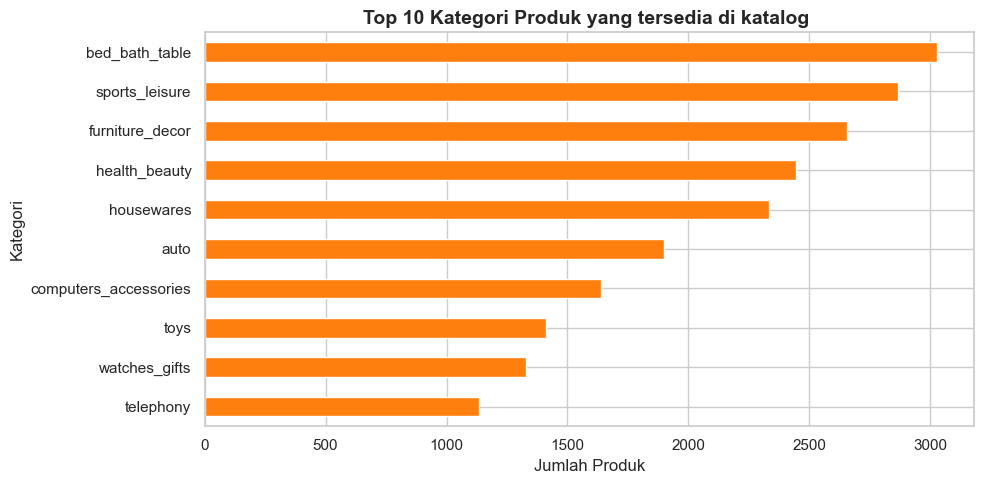

In [28]:
prod_eda = products.copy()
prod_eda['product_category_name'] = prod_eda['product_category_name'].fillna('unknown')

try:
    translation = pd.read_csv('category_translation.csv')
    prod_eda = pd.merge(prod_eda, translation, on='product_category_name', how='left')
    prod_eda['category_display'] = prod_eda['product_category_name_english'].fillna(prod_eda['product_category_name'])
    print('Translasi kategori berhasil.')
except Exception:
    prod_eda['category_display'] = prod_eda['product_category_name']
    print('File translasi tidak ditemukan, menggunakan nama asli.')

display(prod_eda.head())

top_cats = prod_eda['category_display'].value_counts().head(10)
plt.figure(figsize=(10, 5))
top_cats.sort_values().plot(kind='barh', color='#ff7f0e')
plt.title('Top 10 Kategori Produk yang tersedia di katalog ', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Produk', fontsize=12)
plt.ylabel('Kategori', fontsize=12)
plt.tight_layout()
plt.show()

### Insight Products
- Kategori produk terpusat di sejumlah kategori utama.
- Mengetahui kategori paling populer membantu fokus pada pengelolaan stok dan penawaran produk.

### 2.7 Order Reviews


Shape order_reviews: 99,224 baris x 7 kolom


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


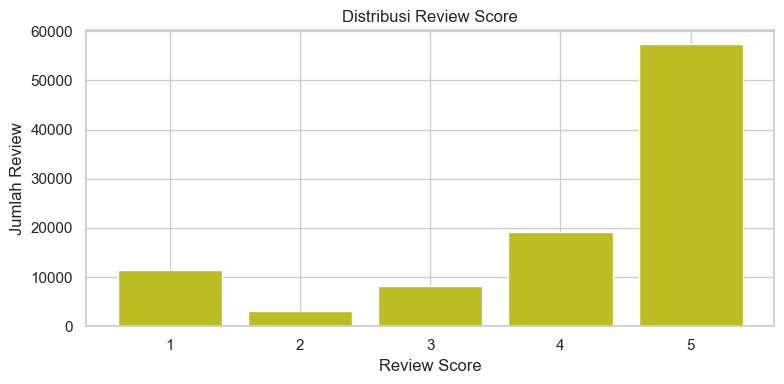

In [21]:
rev_eda = order_reviews.copy()
rev_eda['review_creation_date'] = pd.to_datetime(rev_eda['review_creation_date'], errors='coerce')
rev_eda['review_score'] = pd.to_numeric(rev_eda['review_score'], errors='coerce')

print(f'Shape order_reviews: {rev_eda.shape[0]:,} baris x {rev_eda.shape[1]} kolom')
display(rev_eda.head())

plt.figure(figsize=(8, 4))
review_counts = rev_eda['review_score'].value_counts().sort_index()
plt.bar(review_counts.index.astype(int), review_counts.values, color='#bcbd22')
plt.title('Distribusi Review Score')
plt.xlabel('Review Score')
plt.ylabel('Jumlah Review')
plt.xticks(review_counts.index.astype(int))
plt.tight_layout()
plt.show()

### Insight Order Reviews
- Review score mayoritas berkisar pada nilai tinggi.
- Ini memberi sinyal bahwa kepuasan relatif baik, tetapi keterlambatan dapat mempengaruhi rating.


## 3. Data Cleaning & Feature Engineering
Konversi kolom timestamp, filter pesanan delivered, dan hitung metrik SLA operasional untuk analisis lebih dalam.


In [42]:

# 1. Orders (Cleaning & Feature Engineering Operasional)

print("\n [1/7] Processing Orders...")
# Filter hanya yang delivered
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

# Konversi timestamp
time_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 
             'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in time_cols:
    orders_delivered[col] = pd.to_datetime(orders_delivered[col], errors='coerce')

# Drop baris dengan timestamp kritis yang kosong
orders_delivered.dropna(subset=['order_approved_at', 'order_delivered_customer_date', 'order_delivered_carrier_date'], inplace=True)

# --- Feature Engineering (SLA & Delay) ---
# 1. Approval Time
orders_delivered['approval_time_days'] = (orders_delivered['order_approved_at'] - orders_delivered['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)

# 2. Seller Processing Time (DIKOREKSI: mulai dari approved_at, bukan purchase_timestamp)
orders_delivered['seller_processing_days'] = (orders_delivered['order_delivered_carrier_date'] - orders_delivered['order_approved_at']).dt.total_seconds() / (24 * 3600)

# 3. Carrier Transit Time
orders_delivered['carrier_transit_days'] = (orders_delivered['order_delivered_customer_date'] - orders_delivered['order_delivered_carrier_date']).dt.total_seconds() / (24 * 3600)

# 4. Actual Total Delivery Time
orders_delivered['actual_delivery_days'] = (orders_delivered['order_delivered_customer_date'] - orders_delivered['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)

# 5. Delay Calculation
orders_delivered['delay_days'] = (orders_delivered['order_delivered_customer_date'] - orders_delivered['order_estimated_delivery_date']).dt.total_seconds() / (24 * 3600)
orders_delivered['is_delayed'] = orders_delivered['delay_days'] > 0

print("\n Validasi Nilai Negatif per Stage  (Sebelum Clipping):")
sla_check_cols = ['approval_time_days', 'seller_processing_days', 'carrier_transit_days', 'delay_days']

for col in sla_check_cols:
    negative_count = (orders_delivered[col] < 0).sum()
    if negative_count > 0:
        print(f"   {col}: ditemukan {negative_count:,} baris dengan nilai negatif (anomali waktu).")
    else:
        print(f"   {col}: tidak ada nilai negatif.")

# --- Anomali Handling (Clipping) ---
# Ubah nilai negatif menjadi 0 (karena human error input data tidak boleh merusak rata-rata)
sla_duration_cols = ['approval_time_days', 'seller_processing_days', 'carrier_transit_days']
for col in sla_duration_cols:
    orders_delivered[col] = orders_delivered[col].clip(lower=0)

# 2. Geolocation (Cleaning Duplikat)
print("\n [2/7] Processing Geolocation...")
# KOREKSI PENTING: Menggunakan drop_duplicates jauh lebih aman daripada groupby mean/first 
# untuk dataset Olist, agar tidak menghasilkan koordinat/kota yang tidak valid.
geo_clean = geolocation.drop_duplicates(subset=['geolocation_zip_code_prefix'], keep='first').copy()
print(f"Geolocation bersih: {len(geo_clean):,} baris (dari {len(geolocation):,})")

# 3. Products (Cleaning Kategori & Dimensi - Update Variabel Utama)
print("\n[3/7] Processing Products...")
print(f"Products sebelum cleaning: {len(products):,} baris")

# 1. Isi kategori yang kosong dengan 'unknown'
products['product_category_name'] = products['product_category_name'].fillna('unknown')

# 2. Drop baris yang missing dimensi fisik (krusial untuk analisis biaya pengiriman)
initial_count = len(products)
products.dropna(subset=['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm'], inplace=True)
dropped_count = initial_count - len(products)

print(f"Products setelah cleaning: {len(products):,} baris (Dibuang {dropped_count:,} baris tanpa dimensi fisik)")

# 3. Verifikasi tidak ada missing values lagi
missing_check = products.isnull().sum()[products.isnull().sum() > 0]
if missing_check.empty:
    print(" Verifikasi: Tidak ada missing values tersisa di tabel products.")
else:
    print(" Masih ada missing values:", missing_check)

# 4. ORDER ITEMS (Cleaning Ringan)
print("\n[4/7] Processing Order Items...")
order_items_clean = items.copy()
# Tidak ada missing values, tapi pastikan tipe data harga numerik
order_items_clean['price'] = pd.to_numeric(order_items_clean['price'], errors='coerce')
order_items_clean['freight_value'] = pd.to_numeric(order_items_clean['freight_value'], errors='coerce')
print(f"Order Items bersih: {len(order_items_clean):,} baris")

# 5. SELLERS & CUSTOMERS (Cleaning Tipe Data)
print("\n[5/7] Processing Sellers & Customers...")
sellers_clean = sellers.copy()
# Ubah zip_code menjadi string agar tidak error saat di-JOIN di ClickHouse nanti
sellers_clean['seller_zip_code_prefix'] = sellers_clean['seller_zip_code_prefix'].astype(str)

customers_clean = customers.copy()
customers_clean['customer_zip_code_prefix'] = customers_clean['customer_zip_code_prefix'].astype(str)
print(f"Sellers: {len(sellers_clean):,} | Customers: {len(customers_clean):,} baris")

# 6. ORDER REVIEWS (Cleaning Kolom Teks)
print("\n[6/7] Processing Order Reviews...")
reviews_clean = order_reviews.copy()
# Hapus kolom teks yang 88% kosong (tidak berguna untuk Operational Analyst)
reviews_clean.drop(columns=['review_comment_title', 'review_comment_message'], inplace=True, errors='ignore')
# Konversi tanggal review
reviews_clean['review_creation_date'] = pd.to_datetime(reviews_clean['review_creation_date'], errors='coerce')
print(f"Order Reviews bersih: {len(reviews_clean):,} baris")


# Ringkasan Akhir
print("\n" + "="*60)
print(" SEMUA DATA BERHASIL DI-CLEANING & DI-TRANSFORMASI!")
print("="*60)
print("Variabel yang siap digunakan untuk EDA & Merge:")
print("1. orders_delivered  (Sudah ada metrik SLA & Delay)")
print("2. geo_clean         (Sudah di-deduplikasi)")
print("3. products_clean    (Kategori & dimensi fisik aman)")
print("4. order_items_clean (Harga & freight numerik)")
print("5. sellers_clean     (Zip code bertipe string)")
print("6. customers_clean   (Zip code bertipe string)")
print("7. reviews_clean     (Hanya skor & tanggal)")


 [1/7] Processing Orders...

 Validasi Nilai Negatif per Stage  (Sebelum Clipping):
   approval_time_days: tidak ada nilai negatif.
   seller_processing_days: ditemukan 1,350 baris dengan nilai negatif (anomali waktu).
   carrier_transit_days: ditemukan 23 baris dengan nilai negatif (anomali waktu).
   delay_days: ditemukan 88,630 baris dengan nilai negatif (anomali waktu).

 [2/7] Processing Geolocation...
Geolocation bersih: 19,015 baris (dari 1,000,163)

[3/7] Processing Products...
Products sebelum cleaning: 32,949 baris
Products setelah cleaning: 32,949 baris (Dibuang 0 baris tanpa dimensi fisik)
 Masih ada missing values: product_name_lenght           609
product_description_lenght    609
product_photos_qty            609
dtype: int64

[4/7] Processing Order Items...
Order Items bersih: 112,650 baris

[5/7] Processing Sellers & Customers...
Sellers: 3,095 | Customers: 99,441 baris

[6/7] Processing Order Reviews...
Order Reviews bersih: 99,224 baris

 SEMUA DATA BERHASIL DI-CLEA

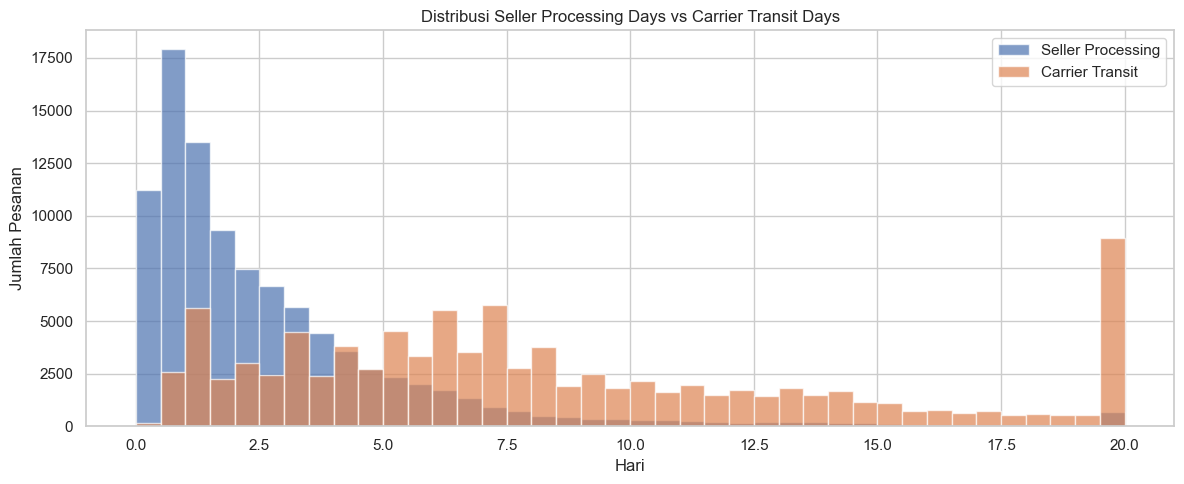

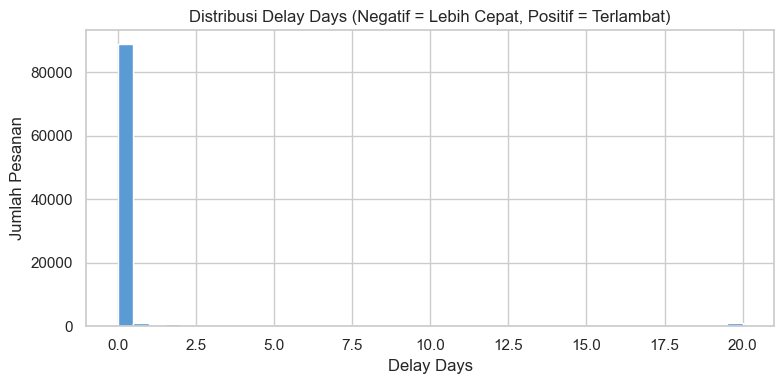

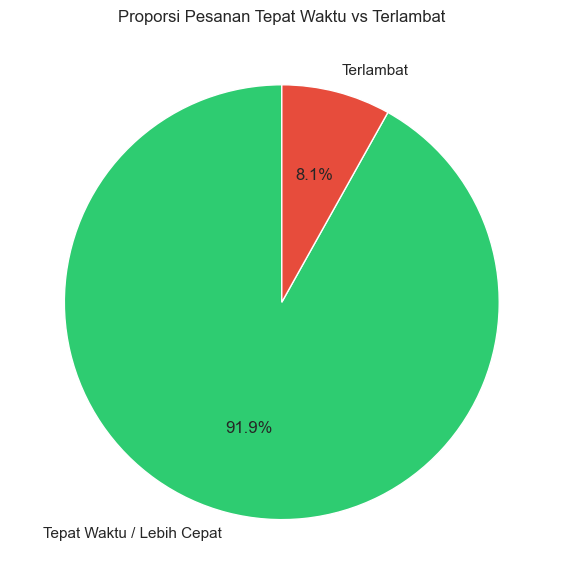

In [40]:
plt.figure(figsize=(12, 5))
plt.hist(orders_delivered['seller_processing_days'].dropna().clip(0, 20), bins=40, alpha=0.7, label='Seller Processing', color='#4c72b0')
plt.hist(orders_delivered['carrier_transit_days'].dropna().clip(0, 20), bins=40, alpha=0.7, label='Carrier Transit', color='#dd8452')
plt.title('Distribusi Seller Processing Days vs Carrier Transit Days')
plt.xlabel('Hari')
plt.ylabel('Jumlah Pesanan')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
orders_delivered['delay_days'].dropna().clip(-10, 20).hist(bins=40, color='#5b9bd5')
plt.title('Distribusi Delay Days (Negatif = Lebih Cepat, Positif = Terlambat)')
plt.xlabel('Delay Days')
plt.ylabel('Jumlah Pesanan')
plt.tight_layout()
plt.show()

delay_counts = orders_delivered['is_delayed'].value_counts(normalize=True) * 100
plt.figure(figsize=(6, 6))
plt.pie(delay_counts.values, labels=['Tepat Waktu / Lebih Cepat', 'Terlambat'], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
plt.title('Proporsi Pesanan Tepat Waktu vs Terlambat')
plt.tight_layout()
plt.show()


### Insight Visualisasi Cleaning
- Sebagian besar waktu SLA tersumbang oleh proses seller dan transit carrier dalam kisaran 0-10 hari.
- Sebagian kecil pesanan menunjukkan keterlambatan lebih dari 0 hari, tetapi ada proporsi signifikan pesanan yang tiba lebih cepat dari estimasi.
- Visualisasi pie menegaskan bahwa mayoritas pesanan tetap tepat waktu meski delay rate tetap perlu diturunkan.


## 4. Kesimpulan
- Setiap tabel diperiksa secara terpisah untuk memahami struktur data dan distribusi kunci.
- Orders menunjukkan berbagai status pengiriman, dan analisis timestamp penting untuk memisahkan record `delivered` yang valid.
- Order Items fokus pada distribusi harga dan produk paling sering dipesan.
- Sellers dan Customers memiliki kekuatan di beberapa state utama, yang bisa menjadi fokus regional operasional.
- Geolocation menyarankan beberapa kota dengan frekuensi lokasi tinggi, penting untuk optimasi rute dan coverage.
- Kategori produk menunjukkan variasi besar, dengan konsentrasi pada top 10 kategori utama.
- Review score cenderung baik, tetapi pesanan terlambat memiliki rata-rata skor lebih rendah.
- Data cleaning dan feature engineering memperjelas SLA operasional: seller processing, carrier transit, actual delivery, dan delay.
- Meskipun mayoritas pesanan tepat waktu, ada peluang peningkatan pada proses seller dan estimasi pengiriman agar delay rate turun lebih jauh.
